In [1]:
import xarray as xr
profile_path = '/data/SO3/edavenport/tpose6/tao_profiles/TAO_WO_2012_ADCP.nc'
ds_adcp = xr.open_dataset(profile_path)

In [2]:
import pandas as pd
# Combine date and time into a datetime array
dates = ds_adcp['prof_YYYYMMDD'].values.astype(int)
times = ds_adcp['prof_HHMMSS'].values.astype(int)

# Convert to zero-padded strings
date_strs = dates.astype(str)
time_strs = times.astype(str)
time_strs = [t.zfill(6) for t in time_strs]  # ensure time is like 'HHMMSS'
# Combine into full datetime strings and convert to pandas datetime
datetime_strs = [d + t for d, t in zip(date_strs, time_strs)]
datetimes = pd.to_datetime(datetime_strs, format='%Y%m%d%H%M%S')

# Assign as coordinate and optionally swap dimensions
ds_adcp = ds_adcp.assign_coords(time=('iPROF', datetimes))
# ds_adcp = ds_adcp.swap_dims({'iPROF': 'time'})
ds_adcp = ds_adcp.assign_coords(depth=('iDEPTH', ds_adcp['prof_depth'].values*-1))
# ds_adcp = ds_adcp.swap_dims({'iDEPTH': 'depth'})
ds_adcp = ds_adcp.assign_coords(lat=('iPROF', ds_adcp['prof_lat'].values))
ds_adcp = ds_adcp.assign_coords(lon=('iPROF', ds_adcp['prof_lon'].values))
# ds_adcp.set_index(lat='lat', lon='lon')


In [3]:
adcp_by_lon = ds_adcp.groupby('lon')

In [4]:
import numpy as np
import warnings
import matplotlib.pyplot as plt
import matplotlib.gridspec as gs
from matplotlib.colors import TwoSlopeNorm
import cmocean.cm as cmo
warnings.filterwarnings("ignore")
plt.rcParams['font.size'] = 13
from xmitgcm import open_mdsdataset
data_dir = '/data/SO3/edavenport/tpose6/sep2012/run_iter0/'
grid_dir = '/data/SO6/TPOSE_diags/tpose6/grid_6/'

num_diags = 122 #
itPerFile = 72 # 1 day
intervals = range(itPerFile,itPerFile*num_diags+1,itPerFile)

prefix = ['diag_state']
ds = open_mdsdataset(data_dir=data_dir,grid_dir=grid_dir,iters=intervals,prefix=prefix,ref_date='2012-09-01',delta_t=1200)
ds['XC'] = ds.XC.astype(float)
ds['YC'] = ds.YC.astype(float)
ds['Z'] = ds.Z.astype(float)
ds['XG'] = ds.XG.astype(float)
ds['YG'] = ds.YG.astype(float)

In [5]:
U6_140 = ds.UVEL.interp(XG=[220.0],YC=[0.0],Z=adcp_by_lon[220.0].depth.values,time=adcp_by_lon[220.0].time.values,method='linear')

U6_TAO_140 = U6_140.copy(deep=True)
U6_TAO_140.values = adcp_by_lon[220.0].prof_U.values[:,:,np.newaxis,np.newaxis]
U6_TAO_140.name = 'U6_TAO_140'
U6_TAO_140 = U6_TAO_140.where(U6_TAO_140 != -9999.0)

U6_110 = ds.UVEL.interp(XG=[250.0],YC=[0.0],Z=adcp_by_lon[250.0].depth.values,time=adcp_by_lon[250.0].time.values,method='linear')

U6_TAO_110 = U6_140.copy(deep=True)
U6_TAO_110.values = adcp_by_lon[250.0].prof_U.values[:,:,np.newaxis,np.newaxis]
U6_TAO_110.name = 'U6_TAO_110'
U6_TAO_110 = U6_TAO_110.where(U6_TAO_110 != -9999.0)

U6_170 = ds.UVEL.interp(XG=[190.0],YC=[0.0],Z=adcp_by_lon[190.0].depth.values,time=adcp_by_lon[190.0].time.values,method='linear')

U6_TAO_170 = U6_170.copy(deep=True)
U6_TAO_170.values = adcp_by_lon[190.0].prof_U.values[:,:,np.newaxis,np.newaxis]
U6_TAO_170.name = 'U6_TAO_170'
U6_TAO_170 = U6_TAO_170.where(U6_TAO_170 != -9999.0)

U6_165E = ds.UVEL.interp(XG=[165.0],YC=[0.0],Z=adcp_by_lon[165.0].depth.values,time=adcp_by_lon[165.0].time.values,method='linear')

U6_TAO_165E = U6_165E.copy(deep=True)
U6_TAO_165E.values = adcp_by_lon[165.0].prof_U.values[:,:,np.newaxis,np.newaxis]
U6_TAO_165E.name = 'U6_TAO_165E'
U6_TAO_165E = U6_TAO_165E.where(U6_TAO_165E != -9999.0)

# -------------------------

V6_140 = ds.VVEL.interp(XC=[220.0],YG=[0.0],Z=adcp_by_lon[220.0].depth.values,time=adcp_by_lon[220.0].time.values,method='linear')

V6_TAO_140 = V6_140.copy(deep=True)
V6_TAO_140.values = adcp_by_lon[220.0].prof_V.values[:,:,np.newaxis,np.newaxis]
V6_TAO_140.name = 'V6_TAO_140'
V6_TAO_140 = V6_TAO_140.where(V6_TAO_140 != -9999.0)

V6_110 = ds.VVEL.interp(XC=[250.0],YG=[0.0],Z=adcp_by_lon[250.0].depth.values,time=adcp_by_lon[250.0].time.values,method='linear')

V6_TAO_110 = V6_140.copy(deep=True)
V6_TAO_110.values = adcp_by_lon[250.0].prof_V.values[:,:,np.newaxis,np.newaxis]
V6_TAO_110.name = 'V6_TAO_110'
V6_TAO_110 = V6_TAO_110.where(V6_TAO_110 != -9999.0)

V6_170 = ds.VVEL.interp(XC=[190.0],YG=[0.0],Z=adcp_by_lon[190.0].depth.values,time=adcp_by_lon[190.0].time.values,method='linear')

V6_TAO_170 = V6_170.copy(deep=True)
V6_TAO_170.values = adcp_by_lon[190.0].prof_V.values[:,:,np.newaxis,np.newaxis]
V6_TAO_170.name = 'V6_TAO_170'
V6_TAO_170 = V6_TAO_170.where(V6_TAO_170 != -9999.0)

V6_165E = ds.VVEL.interp(XC=[165.0],YG=[0.0],Z=adcp_by_lon[165.0].depth.values,time=adcp_by_lon[165.0].time.values,method='linear')

V6_TAO_165E = V6_165E.copy(deep=True)
V6_TAO_165E.values = adcp_by_lon[165.0].prof_V.values[:,:,np.newaxis,np.newaxis]
V6_TAO_165E.name = 'V6_TAO_165E'
V6_TAO_165E = V6_TAO_165E.where(V6_TAO_165E != -9999.0)

U6_TAO_140 = U6_TAO_140.sel(time=slice('2012-09-01', None))
V6_TAO_140 = V6_TAO_140.sel(time=slice('2012-09-01', None))
U6_140 = U6_140.sel(time=slice('2012-09-01', None))
V6_140 = V6_140.sel(time=slice('2012-09-01', None))

U6_TAO_110 = U6_TAO_110.sel(time=slice('2012-09-01', None))
V6_TAO_110 = V6_TAO_110.sel(time=slice('2012-09-01', None))
U6_110 = U6_110.sel(time=slice('2012-09-01', None))
V6_110 = V6_110.sel(time=slice('2012-09-01', None))

U6_TAO_170 = U6_TAO_170.sel(time=slice('2012-09-01', None))
V6_TAO_170 = V6_TAO_170.sel(time=slice('2012-09-01', None))
U6_170 = U6_170.sel(time=slice('2012-09-01', None))
V6_170 = V6_170.sel(time=slice('2012-09-01', None))

depths = U6_TAO_140.Z.values

zMax = -35
zMin = -250
Udepthli = np.argmin(np.abs(depths - zMax))
Udepthui = np.argmin(np.abs(depths - zMin)) + 1

# crop the time series to the depths we are interested in to get rid of NaNs before computing covariance
U6_140 = U6_140[3:,Udepthli:Udepthui,0,0]
U6_TAO_140 = U6_TAO_140[3:,Udepthli:Udepthui,0,0]
U6_TAO_140 = U6_TAO_140.where(~np.isnan(U6_TAO_140),0.0)
U6_140 = U6_140.where(~np.isnan(U6_140),0.0)

V6_140 = V6_140[3:,Udepthli:Udepthui,0,0]
V6_TAO_140 = V6_TAO_140[3:,Udepthli:Udepthui,0,0]
V6_TAO_140 = V6_TAO_140.where(~np.isnan(V6_TAO_140),0.0)
V6_140 = V6_140.where(~np.isnan(V6_140),0.0)

U6_110 = U6_110[3:,Udepthli:Udepthui,0,0]
U6_TAO_110 = U6_TAO_110[3:,Udepthli:Udepthui,0,0]
U6_TAO_110 = U6_TAO_110.where(~np.isnan(U6_TAO_110),0.0)
U6_110 = U6_110.where(~np.isnan(U6_110),0.0)

V6_110 = V6_110[3:,Udepthli:Udepthui,0,0]
V6_TAO_110 = V6_TAO_110[3:,Udepthli:Udepthui,0,0]
V6_TAO_110 = V6_TAO_110.where(~np.isnan(V6_TAO_110),0.0)
V6_110 = V6_110.where(~np.isnan(V6_110),0.0)

U6_170 = U6_170[3:,Udepthli:Udepthui,0,0]
U6_TAO_170 = U6_TAO_170[3:,Udepthli:Udepthui,0,0]
U6_TAO_170 = U6_TAO_170.where(~np.isnan(U6_TAO_170),0.0)
U6_170 = U6_170.where(~np.isnan(U6_170),0.0)

V6_170 = V6_170[3:,Udepthli:Udepthui,0,0]
V6_TAO_170 = V6_TAO_170[3:,Udepthli:Udepthui,0,0]
V6_TAO_170 = V6_TAO_170.where(~np.isnan(V6_TAO_170),0.0)
V6_170 = V6_170.where(~np.isnan(V6_170),0.0)

In [6]:
# Compute depth-depthcovariance 
cov_depth_U_140 = np.cov(U6_140, rowvar=False)  # rowvar=False => each column is a variable (depth)
cov_depth_U_TAO_140 = np.cov(U6_TAO_140, rowvar=False)  # rowvar=False => each column is a variable (depth)
cov_depth_V_140 = np.cov(V6_140, rowvar=False)  # rowvar=False => each column is a variable (depth)
cov_depth_V_TAO_140 = np.cov(V6_TAO_140, rowvar=False)  # rowvar=False => each column is a variable (depth)
cov_depth_U_110 = np.cov(U6_110, rowvar=False)  # rowvar=False => each column is a variable (depth)
cov_depth_U_TAO_110 = np.cov(U6_TAO_110, rowvar=False)  # rowvar=False => each column is a variable (depth)
cov_depth_V_110 = np.cov(V6_110, rowvar=False)  # rowvar=False => each column is a variable (depth)
cov_depth_V_TAO_110 = np.cov(V6_TAO_110, rowvar=False)  # rowvar=False => each column is a variable (depth)
cov_depth_U_170 = np.cov(U6_170, rowvar=False)  # rowvar=False => each column is a variable (depth)
cov_depth_U_TAO_170 = np.cov(U6_TAO_170, rowvar=False)  # rowvar=False => each column is a variable (depth)
cov_depth_V_170 = np.cov(V6_170, rowvar=False)  # rowvar=False => each column is a variable (depth)
cov_depth_V_TAO_170 = np.cov(V6_TAO_170, rowvar=False)  # rowvar=False => each column is a variable (depth)


In [7]:
# compute depth-depth correlation
corr_depth_U_140 = np.corrcoef(U6_140, rowvar=False)  # rowvar=False => each column is a variable (depth)
corr_depth_U_TAO_140 = np.corrcoef(U6_TAO_140, rowvar=False) 
corr_depth_V_140 = np.corrcoef(V6_140, rowvar=False)  
corr_depth_V_TAO_140 = np.corrcoef(V6_TAO_140, rowvar=False) 
corr_depth_U_110 = np.corrcoef(U6_110, rowvar=False)
corr_depth_U_TAO_110 = np.corrcoef(U6_TAO_110, rowvar=False) 
corr_depth_V_110 = np.corrcoef(V6_110, rowvar=False) 
corr_depth_V_TAO_110 = np.corrcoef(V6_TAO_110, rowvar=False)  
corr_depth_U_170 = np.corrcoef(U6_170, rowvar=False)  
corr_depth_U_TAO_170 = np.corrcoef(U6_TAO_170, rowvar=False)  
corr_depth_V_170 = np.corrcoef(V6_170, rowvar=False)  
corr_depth_V_TAO_170 = np.corrcoef(V6_TAO_170, rowvar=False)  

## Plotting

In [8]:
# plot with imshow
def plot_corr(cov_matrix, Z, title, ax):
    im = ax.pcolormesh(Z, Z, cov_matrix, cmap=cmo.balance, vmin=-1, vmax=1)
    ax.set_title(title)
    ax.set_xlabel('')
    ax.set_ylabel('')
    plt.colorbar(im, ax=ax)

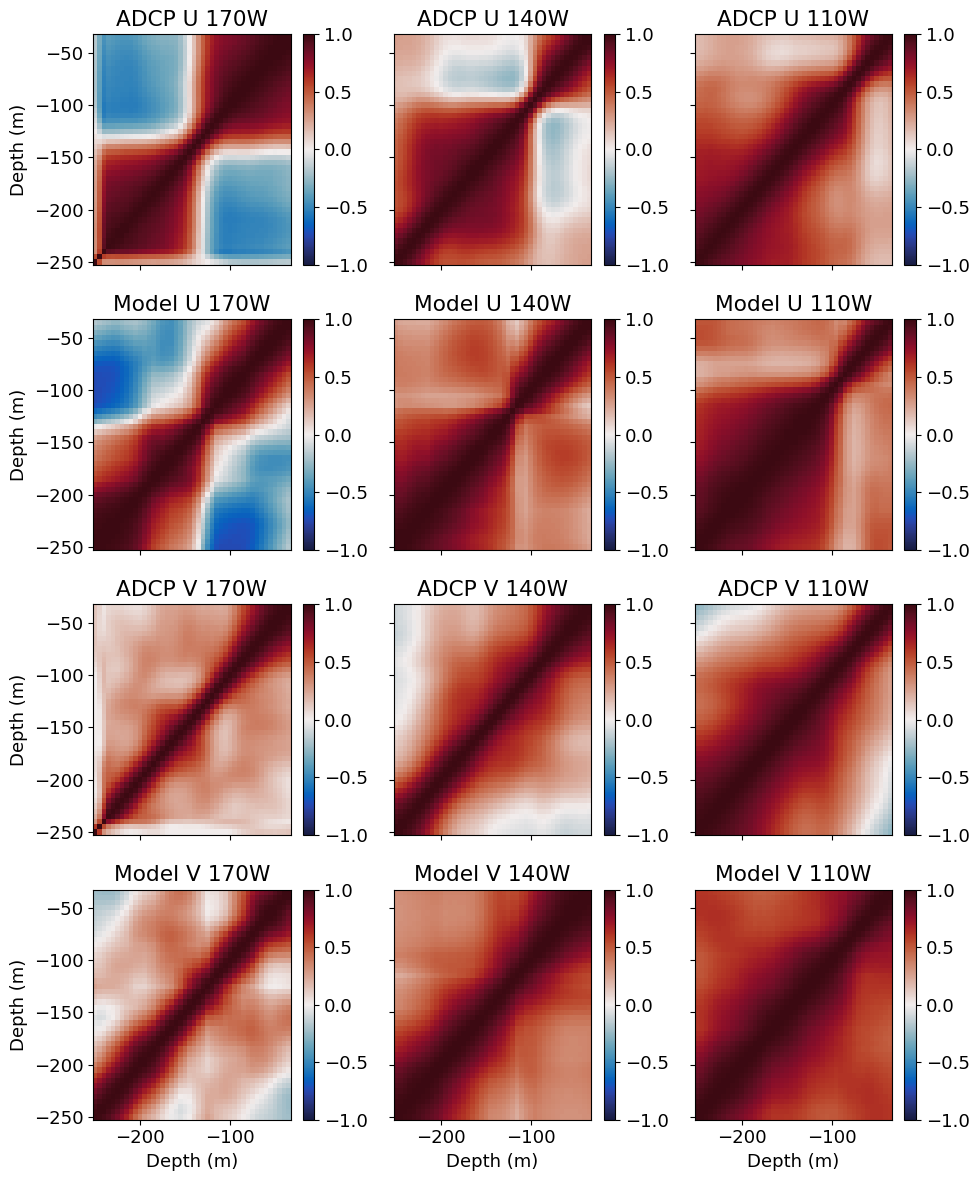

In [9]:
fig, axs = plt.subplots(nrows=4, ncols=3, figsize=(10, 12), sharex=True, sharey=True)
plot_corr(corr_depth_U_TAO_170, U6_170.Z, 'ADCP U 170W', axs[0, 0])
plot_corr(corr_depth_U_170, U6_170.Z, 'Model U 170W', axs[1, 0])
plot_corr(corr_depth_U_TAO_140, U6_140.Z, 'ADCP U 140W', axs[0, 1])
plot_corr(corr_depth_U_140, U6_140.Z, 'Model U 140W', axs[1, 1])
plot_corr(corr_depth_U_TAO_110, U6_110.Z, 'ADCP U 110W', axs[0, 2])
plot_corr(corr_depth_U_110, U6_110.Z, 'Model U 110W', axs[1, 2])

axs[0,0].set_ylabel('Depth (m)')
axs[1,0].set_ylabel('Depth (m)')

plot_corr(corr_depth_V_TAO_170, V6_170.Z, 'ADCP V 170W', axs[2, 0])
plot_corr(corr_depth_V_170, V6_170.Z, 'Model V 170W', axs[3, 0])
plot_corr(corr_depth_V_TAO_140, V6_140.Z, 'ADCP V 140W', axs[2, 1])
plot_corr(corr_depth_V_140, V6_140.Z, 'Model V 140W', axs[3, 1])
plot_corr(corr_depth_V_TAO_110, V6_110.Z, 'ADCP V 110W', axs[2, 2])
plot_corr(corr_depth_V_110, V6_110.Z, 'Model V 110W', axs[3, 2])
axs[2,0].set_ylabel('Depth (m)')
axs[3,0].set_ylabel('Depth (m)')
axs[3,0].set_xlabel('Depth (m)')
axs[3,1].set_xlabel('Depth (m)')
axs[3,2].set_xlabel('Depth (m)')

plt.tight_layout()
plt.savefig('/home/edavenport/analysis/vel-assim-manuscript/representation_error/depthdepth_corr.png')